# Distance-threshold classification & plots for documentation (manual threshold)

Dieses Notebook entspricht der bisherigen Pipeline, **mit einem Unterschied**:

- die **Schwelle wird nicht automatisch berechnet**, sondern **manuell gesetzt**
- alle nachfolgenden Auswertungen (Histogramm mit Threshold, Confusion Matrix, ROC-Markierung, optionale Scatter/Bland-Altman-Plots) bleiben erhalten

Du setzt die finale Schwelle direkt im Setup über `THR_FINAL_MM`.



## 0) Setup & Konfiguration


In [61]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

# -----------------------------
# Pfade (an deine Umgebung anpassen)
# -----------------------------

#Vxm
#DIST_CSV = Path("/home/students/studunals1/biopsy_project/z_MAschreiben/4_2/4_2_4/dist_pred_lesion_gt_needletip_LOSS_AXIAL_new_sweep.csv")
#Transmorph
DIST_CSV = Path("/home/students/studunals1/biopsy_project/z_MAschreiben/4_3/4_3_2_Axial_Loss/dist_pred_lesion_gt_needletip_vxm.csv")
#GmaRaft
#DIST_CSV = Path("/home/students/studunals1/biopsy_project/z_MAschreiben/4_4/4_4_4/dist_pred_lesion_gt_needletip_vxm.csv")

GT_LABEL_CSV = Path("/home/students/studunals1/biopsy_project/vxm/csv/Breast_MRI_Biopsy_anonym.csv")

# Optional: GT-Distanz-CSV (für Scatter + Bland-Altman)
# (nur nutzen, wenn vorhanden; sonst wird der Teil übersprungen)
GT_DIST_CSV = Path("/home/students/studunals1/biopsy_project/z_MAschreiben/dist_gt_lesion_gt_needletip.csv")

# Output-Ordner für Doku-Plots
PLOT_DIR = Path("./plots_doc_manual_threshold")
PLOT_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# Spaltennamen / Semantik
# -----------------------------
PRED_DIST_COL = "dist_pred_lesion_gt_needletip_mm"               # predicted lesion↔needle distance [mm]
GT_ID_COL     = "AnonymID"                                  # ID in Label-CSV
GT_LABEL_COL  = "Repräsentative Biopsie Ja (0), Nein (1)"   # 0=repr, 1=non-repr (positiv)

# Klassifikations-Regel:
# pred=1 (non-repr) wenn dist > threshold
PRED_POSITIVE_IF = ">"  # ">" oder ">="

# -----------------------------
# Finale Schwelle MANUELL setzen
# -----------------------------
THR_FINAL_MM = 7.85  # <-- HIER DEINE SCHWELLE EINTRAGEN

print("DIST_CSV:", DIST_CSV, "| exists:", DIST_CSV.exists())
print("GT_LABEL_CSV:", GT_LABEL_CSV, "| exists:", GT_LABEL_CSV.exists())
print("GT_DIST_CSV (optional):", GT_DIST_CSV, "| exists:", GT_DIST_CSV.exists())
print("PLOT_DIR:", PLOT_DIR.resolve())
print("THR_FINAL_MM:", THR_FINAL_MM)



DIST_CSV: /home/students/studunals1/biopsy_project/z_MAschreiben/4_3/4_3_2_Axial_Loss/dist_pred_lesion_gt_needletip_vxm.csv | exists: True
GT_LABEL_CSV: /home/students/studunals1/biopsy_project/vxm/csv/Breast_MRI_Biopsy_anonym.csv | exists: True
GT_DIST_CSV (optional): /home/students/studunals1/biopsy_project/z_MAschreiben/dist_gt_lesion_gt_needletip.csv | exists: True
PLOT_DIR: /mnt/ceph/vol_02_home_students/studunals1/biopsy_project/z_MAschreiben/plots_doc_manual_threshold
THR_FINAL_MM: 7.85


## 1) Utilities (robustes CSV-Lesen, Metriken, Plot-Helper)


In [62]:
def read_csv_robust(path: Path) -> pd.DataFrame:
    """Robustes Lesen bei unbekanntem Separator/Encoding."""
    seps = [",", ";", "\t", "|"]
    encodings = ["utf-8", "utf-8-sig", "cp1252", "latin1"]

    last_err = None
    for enc in encodings:
        for sep in seps:
            try:
                df = pd.read_csv(path, sep=sep, encoding=enc)
                if df.shape[1] <= 1:
                    continue
                return df
            except Exception as e:
                last_err = e

    raise RuntimeError(f"CSV konnte nicht robust gelesen werden: {path}\nLetzter Fehler: {last_err}")

def to_str_series(s: pd.Series) -> pd.Series:
    """Sicheres Casting zu String (ohne .0 bei ints)."""
    return s.astype(str).str.replace(r"\.0$", "", regex=True).str.strip()

def predict_from_threshold(d: np.ndarray, thr: float, rule: str = ">") -> np.ndarray:
    if rule == ">":
        return (d > thr).astype(int)
    if rule == ">=":
        return (d >= thr).astype(int)
    raise ValueError("rule must be '>' or '>='")

def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    tpr = tp/(tp+fn) if (tp+fn) else np.nan  # Sensitivity
    tnr = tn/(tn+fp) if (tn+fp) else np.nan  # Specificity
    bac = 0.5*(tpr+tnr) if (np.isfinite(tpr) and np.isfinite(tnr)) else np.nan
    acc = (tp+tn)/ (tp+tn+fp+fn) if (tp+tn+fp+fn) else np.nan
    return {
        "TP": int(tp), "TN": int(tn), "FP": int(fp), "FN": int(fn),
        "TPR": float(tpr), "TNR": float(tnr),
        "BAC": float(bac), "ACC": float(acc)
    }

def savefig(fig, filename: str):
    out = PLOT_DIR / filename
    fig.savefig(out, dpi=300, bbox_inches="tight")
    print("Saved:", out)

def plot_confmat_counts_perc(cm: np.ndarray, title: str, fname: str | None = None):
    """Confusion matrix mit Anzahl + Prozent (für Doku)."""
    cm = np.asarray(cm, dtype=float)
    total = cm.sum()
    perc = (cm / total * 100.0) if total else np.zeros_like(cm)

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.imshow(cm, interpolation="nearest", cmap="Blues")
    ax.set_title(title)
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("Ground truth class")
    ax.set_xticks([0,1], ["pred 0 (repr)", "pred 1 (non-repr)"])
    ax.set_yticks([0,1], ["GT 0 (repr)", "GT 1 (non-repr)"])

    # Labels in den Feldern
    for i in range(2):
        for j in range(2):
            ax.text(
                j, i,
                f"{int(cm[i,j])}\n{perc[i,j]:.1f}%",
                ha="center", va="center",
                color="black"
            )

    # Gitter
    ax.set_xticks(np.arange(-.5, 2, 1), minor=True)
    ax.set_yticks(np.arange(-.5, 2, 1), minor=True)
    ax.grid(which="minor", linewidth=1)
    ax.tick_params(which="minor", bottom=False, left=False)

    plt.tight_layout()
    if fname:
        savefig(fig, fname)
    plt.show()
    return fig


## 2) Daten laden & mergen (Pred-Distanz + GT-Label)


In [63]:
# --- Distanz-Predictions laden ---
dist_df = read_csv_robust(DIST_CSV)
if "patient_id" not in dist_df.columns:
    raise KeyError(f"dist_df: patient_id nicht gefunden. Spalten: {list(dist_df.columns)}")
if PRED_DIST_COL not in dist_df.columns:
    raise KeyError(f"dist_df: {PRED_DIST_COL} nicht gefunden. Spalten: {list(dist_df.columns)}")

dist_df = dist_df.copy()
dist_df["patient_id"] = to_str_series(dist_df["patient_id"])
dist_df[PRED_DIST_COL] = pd.to_numeric(dist_df[PRED_DIST_COL], errors="coerce")

print("dist_df shape:", dist_df.shape)
display(dist_df.head())

# --- GT-Label laden ---
gt_df = read_csv_robust(GT_LABEL_CSV)
for c in [GT_ID_COL, GT_LABEL_COL]:
    if c not in gt_df.columns:
        raise KeyError(f"gt_df: Spalte '{c}' nicht gefunden. Spalten: {list(gt_df.columns)}")

gt_df = gt_df.copy()
gt_df[GT_ID_COL] = to_str_series(gt_df[GT_ID_COL])
gt_df[GT_LABEL_COL] = pd.to_numeric(gt_df[GT_LABEL_COL], errors="coerce")

# Doppelte IDs robust behandeln: pro ID ersten nicht-NaN Wert
tmp = gt_df[[GT_ID_COL, GT_LABEL_COL]].sort_values(GT_ID_COL)
gt_map = (tmp.groupby(GT_ID_COL)[GT_LABEL_COL]
            .apply(lambda s: s.dropna().iloc[0] if len(s.dropna()) else np.nan)
            .reset_index()
            .rename(columns={GT_ID_COL: "patient_id", GT_LABEL_COL: "ground_truth"}))

merged = dist_df.merge(gt_map, on="patient_id", how="left")

print("merged shape:", merged.shape)
print("Missing ground_truth:", merged["ground_truth"].isna().sum(), "/", len(merged))
display(merged.head())

# Für die Auswertung: nur gültige GT + Distanz
df = merged.dropna(subset=[PRED_DIST_COL, "ground_truth"]).copy()
df["ground_truth"] = pd.to_numeric(df["ground_truth"], errors="coerce").astype(int)
df[PRED_DIST_COL] = pd.to_numeric(df[PRED_DIST_COL], errors="coerce")
df = df.dropna(subset=[PRED_DIST_COL]).copy()

y = df["ground_truth"].to_numpy()  # 0=repr, 1=non-repr (positiv)
x = df[PRED_DIST_COL].to_numpy()

print("N=", len(df), "| positives (1)=", int((y==1).sum()), "| negatives (0)=", int((y==0).sum()))


dist_df shape: (45, 4)


,patient_id,study_id,breast_side,dist_pred_lesion_gt_needletip_mm
0,10744914,20210927101351_20210927,rechts,13.349126
1,10781279,20200316104807_20200316,links,3.447552
2,10929783,20240828095756_20240828,links,8.165087
3,10962257,20200729104854_20200729,rechts,4.555389
4,11211512,20210308092303_20210308,links,7.765702


merged shape: (45, 5)
Missing ground_truth: 1 / 45


,patient_id,study_id,breast_side,dist_pred_lesion_gt_needletip_mm,ground_truth
0,10744914,20210927101351_20210927,rechts,13.349126,1.0
1,10781279,20200316104807_20200316,links,3.447552,0.0
2,10929783,20240828095756_20240828,links,8.165087,0.0
3,10962257,20200729104854_20200729,rechts,4.555389,0.0
4,11211512,20210308092303_20210308,links,7.765702,1.0


N= 44 | positives (1)= 22 | negatives (0)= 22


### Optional: merged CSV speichern (für späteres Re-Use)


In [64]:
OUT_MERGED = DIST_CSV.with_name(DIST_CSV.stem + "_with_groundtruth.csv")
df.to_csv(OUT_MERGED, index=False)
print("Saved:", OUT_MERGED)


Saved: /home/students/studunals1/biopsy_project/z_MAschreiben/4_3/4_3_2_Axial_Loss/dist_pred_lesion_gt_needletip_vxm_with_groundtruth.csv


## 3) Deskriptive Statistiken + Basis-Plots (Histogramm, Boxplot)


In [65]:
# Statistik-Tabelle (für Doku)
s = pd.to_numeric(df[PRED_DIST_COL], errors="coerce").dropna()

stats = pd.DataFrame({
    "Kennwert": [
        "n",
        "mean [mm]",
        "std [mm]",
        "min [mm]",
        "25% (Q1) [mm]",
        "median (50%) [mm]",
        "75% (Q3) [mm]",
        "max [mm]",
    ],
    "Wert": [
        int(s.shape[0]),
        float(s.mean()),
        float(s.std(ddof=1)),
        float(s.min()),
        float(s.quantile(0.25)),
        float(s.median()),
        float(s.quantile(0.75)),
        float(s.max()),
    ]
})
display(stats)


,Kennwert,Wert
0,n,44.000000
1,mean [mm],7.188819
2,std [mm],4.367442
3,min [mm],0.989900
4,25% (Q1) [mm],3.965242
5,median (50%) [mm],6.617137
6,75% (Q3) [mm],9.527558
7,max [mm],19.431151


Saved: plots_doc_manual_threshold/hist_pred_distance_all.png


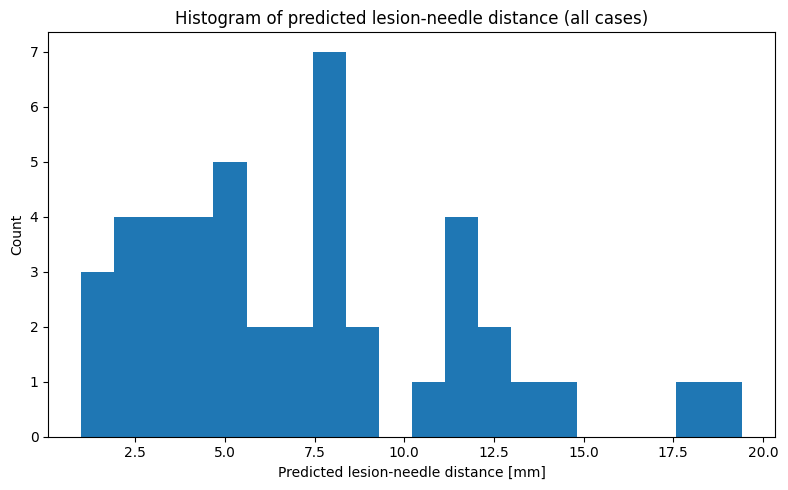

In [66]:
# Histogramm (alle Fälle)
fig = plt.figure(figsize=(8,5))
plt.hist(x, bins=20)
plt.title("Histogram of predicted lesion-needle distance (all cases)")
plt.xlabel("Predicted lesion-needle distance [mm]")
plt.ylabel("Count")
plt.tight_layout()
savefig(fig, "hist_pred_distance_all.png")
plt.show()


/tmp/ipykernel_1935973/1054991263.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data0, data1], labels=["GT=0 (repr)", "GT=1 (non-repr)"])


Saved: plots_doc_manual_threshold/boxplot_pred_distance_by_gt.png


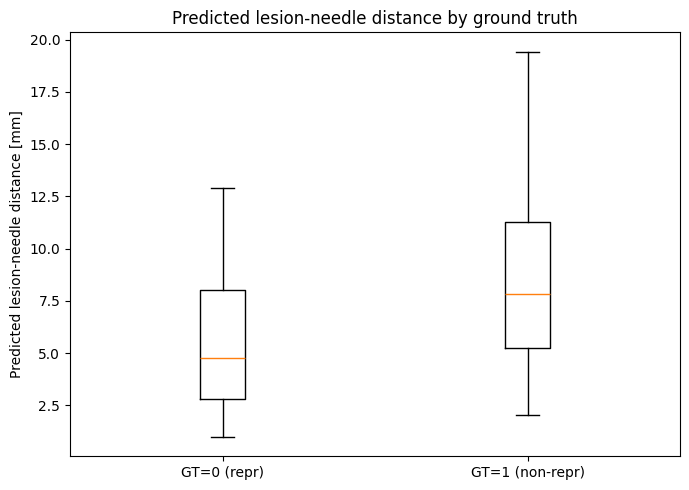

In [67]:
# Boxplot nach Ground Truth
data0 = df.loc[df["ground_truth"]==0, PRED_DIST_COL].to_numpy()
data1 = df.loc[df["ground_truth"]==1, PRED_DIST_COL].to_numpy()

fig = plt.figure(figsize=(7,5))
plt.boxplot([data0, data1], labels=["GT=0 (repr)", "GT=1 (non-repr)"])
plt.title("Predicted lesion-needle distance by ground truth")
plt.ylabel("Predicted lesion-needle distance [mm]")
plt.tight_layout()
savefig(fig, "boxplot_pred_distance_by_gt.png")
plt.show()


## 4) Finale Schwelle manuell setzen und anwenden


THR_FINAL = 7.85
Saved: plots_doc_manual_threshold/hist_pred_distance_with_thr.png


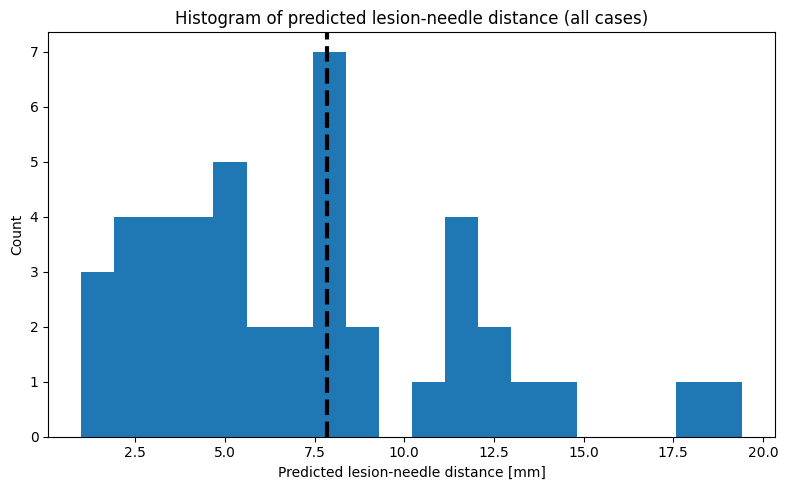

Final metrics: {'TP': 11, 'TN': 16, 'FP': 6, 'FN': 11, 'TPR': 0.5, 'TNR': 0.7272727272727273, 'BAC': 0.6136363636363636, 'ACC': 0.6136363636363636}


In [68]:
THR_FINAL = float(THR_FINAL_MM)

if not np.isfinite(THR_FINAL):
    raise ValueError(f"THR_FINAL_MM ist nicht endlich: {THR_FINAL_MM}")

print("THR_FINAL =", THR_FINAL)

# Histogramm + markierte Schwelle (für Doku)
fig = plt.figure(figsize=(8,5))
plt.hist(x, bins=20)
plt.axvline(THR_FINAL, linestyle="--", linewidth=3, color="black")
plt.title("Histogram of predicted lesion-needle distance (all cases)")
plt.xlabel("Predicted lesion-needle distance [mm]")
plt.ylabel("Count")
plt.tight_layout()
savefig(fig, "hist_pred_distance_with_thr.png")
plt.show()

# Vorhersagen bei manuell gesetzter Schwelle
yhat_final = predict_from_threshold(x, THR_FINAL, rule=PRED_POSITIVE_IF)
m_final = compute_metrics(y, yhat_final)
print("Final metrics:", m_final)



## 5) Confusion Matrix für THR_FINAL


Saved: plots_doc_manual_threshold/confusion_matrix_final.png


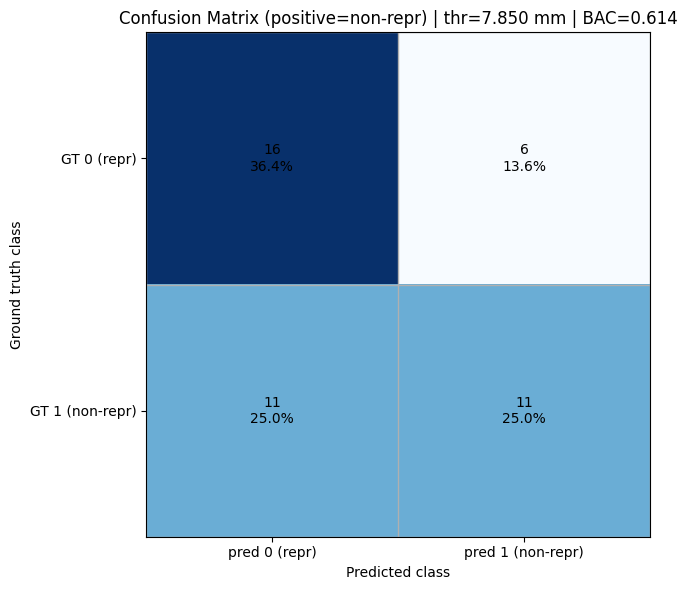

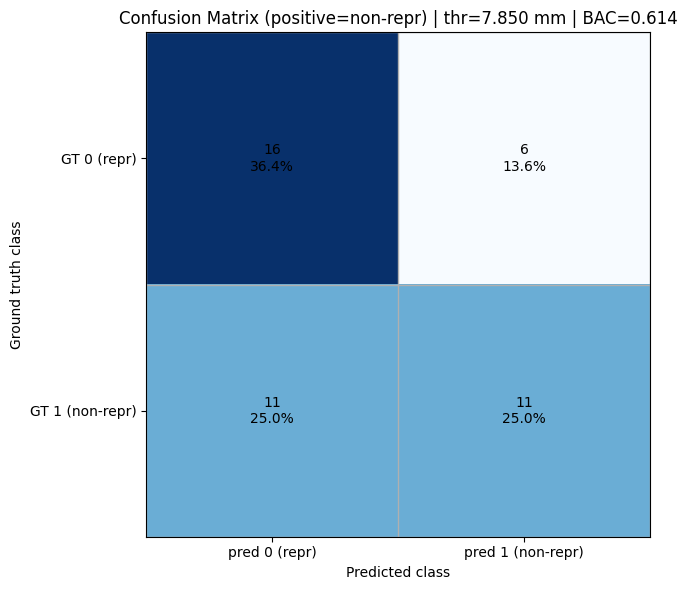

In [69]:
cm = np.array([
    [m_final["TN"], m_final["FP"]],
    [m_final["FN"], m_final["TP"]],
], dtype=int)

plot_confmat_counts_perc(
    cm,
    title=f"Confusion Matrix (positive=non-repr) | thr={THR_FINAL:.3f} mm | BAC={m_final['BAC']:.3f}",
    fname="confusion_matrix_final.png"
)



## 6) ROC-Kurve (AUC) + Markierung der manuellen Schwelle


In [70]:
auc = roc_auc_score(y, x)
fpr, tpr, thr_roc = roc_curve(y, x)  # sklearn: größere Scores → positive Klasse (1)

fig = plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f"ROC (AUC={auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--", label="Chance")

def mark_threshold(thr_value, text):
    idx = int(np.argmin(np.abs(thr_roc - thr_value)))
    plt.scatter([fpr[idx]], [tpr[idx]])
    plt.text(fpr[idx], tpr[idx], f" {text}
 thr={thr_value:.2f}", fontsize=9)

mark_threshold(float(THR_FINAL), "FINAL")

plt.title("ROC curve for predicted lesion-needle distance")
plt.xlabel("False Positive Rate (1 - TNR)")
plt.ylabel("True Positive Rate (TPR)")
plt.legend()
plt.tight_layout()
savefig(fig, "roc_auc.png")
plt.show()



SyntaxError: unterminated string literal (detected at line 11) (2492360900.py, line 11)

## 7) Optional: Predicted distance vs. GT distance (Scatter + Bland-Altman)
Wird nur ausgeführt, wenn `GT_DIST_CSV` existiert und eine passende Spalte gefunden wird.


In [ ]:
if not GT_DIST_CSV.exists():
    print("GT_DIST_CSV nicht gefunden → Scatter/Bland-Altman wird übersprungen.")
else:
    pred = df[["patient_id", PRED_DIST_COL, "ground_truth"]].copy()
    gt = read_csv_robust(GT_DIST_CSV).copy()

    pred["patient_id"] = to_str_series(pred["patient_id"])
    gt["patient_id"] = to_str_series(gt["patient_id"])

    # mögliche GT-Spaltennamen (inkl. Tippfehler aus alten Dateien)
    gt_col_candidates = [
        "gt_distance_lesion_neddletip",
        "gt_distance_lesion_needletip",
        "gt_distance_lesion_neddletip ",
        "gt_distance_lesion_needletip ",
    ]
    gt_col = next((c for c in gt_col_candidates if c in gt.columns), None)
    if gt_col is None:
        raise ValueError(f"Keine GT-Distanz-Spalte gefunden. Vorhandene Spalten: {list(gt.columns)}")

    gt[gt_col] = pd.to_numeric(gt[gt_col], errors="coerce")
    pred[PRED_DIST_COL] = pd.to_numeric(pred[PRED_DIST_COL], errors="coerce")

    merged_dist = pred.merge(gt[["patient_id", gt_col]], on="patient_id", how="inner").dropna()
    print("merged_dist shape:", merged_dist.shape)
    display(merged_dist.head())

    x_gt = merged_dist[gt_col].to_numpy()
    y_pred = merged_dist[PRED_DIST_COL].to_numpy()

    # --- Scatter mit Regression + 1:1 Skalierung ---
    r = np.corrcoef(x_gt, y_pred)[0,1]
    a, b = np.polyfit(x_gt, y_pred, 1)
    xx = np.linspace(x_gt.min(), x_gt.max(), 200)
    yy = a*xx + b

    fig = plt.figure(figsize=(8,5))
    plt.scatter(x_gt, y_pred)
    plt.plot(xx, yy, linestyle="--")
    mn = min(x_gt.min(), y_pred.min())
    mx = max(x_gt.max(), y_pred.max())
    pad = 0.05*(mx-mn) if mx>mn else 1.0
    plt.xlim(mn-pad, mx+pad)
    plt.ylim(mn-pad, mx+pad)
    plt.gca().set_aspect("equal", adjustable="box")
    plt.title(f"Scatter plot GT vs. predicted lesion-needle distance\n(Pearson r = {r:.2f})")
    plt.xlabel("GT lesion-needle distance [mm]")
    plt.ylabel("Predicted lesion-needle distance [mm]")
    plt.tight_layout()
    savefig(fig, "scatter_gt_vs_pred.png")
    plt.show()

    # --- Bland-Altman ---
    mean = (x_gt + y_pred)/2
    diff = (y_pred - x_gt)

    md = float(np.mean(diff))
    sd = float(np.std(diff, ddof=1))
    loa_upper = md + 1.96*sd
    loa_lower = md - 1.96*sd

    fig = plt.figure(figsize=(8,5))
    plt.scatter(mean, diff)
    plt.axhline(md, linewidth=2)
    plt.axhline(loa_upper, linestyle="--", linewidth=2)
    plt.axhline(loa_lower, linestyle="--", linewidth=2)
    plt.title("Bland-Altman: Predicted vs GT lesion-needle distance")
    plt.xlabel("Mean of GT and Predicted [mm]")
    plt.ylabel("Difference (Pred - GT) [mm]")
    plt.tight_layout()
    savefig(fig, "bland_altman.png")
    plt.show()

    print(f"Mean diff (bias): {md:.3f} mm")
    print(f"LoA: [{loa_lower:.3f}, {loa_upper:.3f}] mm")


merged_dist shape: (45, 4)


,patient_id,gt_distance_lesion_neddletip_x,ground_truth,gt_distance_lesion_neddletip_y
0,10744914,14.964716,1,14.964716
1,10781279,3.921332,0,3.921332
2,10929783,11.197339,0,11.197339
3,10962257,2.270433,0,2.270433
4,11211512,13.310756,1,13.310756


KeyError: 'gt_distance_lesion_neddletip'

## 8) Kurzübersicht: Welche Dateien wurden exportiert?


In [ ]:
# Liste exportierter Dateien
exports = sorted([p.name for p in PLOT_DIR.glob("*") if p.is_file()])
print("Exported plots:")
for f in exports:
    print(" -", f)


Exported plots:
 - bac_vs_threshold.png
 - bland_altman.png
 - boxplot_pred_distance_by_gt.png
 - confusion_matrix_final.png
 - hist_pred_distance_all.png
 - hist_pred_distance_with_thr.png
 - roc_auc.png
 - scatter_gt_vs_pred.png
